In [3]:
import pandas as pd
df = pd.read_csv('/wellbeing-local-authority-time-series-v4.csv')
df.head()

,v4_3,Data marking,Lower limit,Upper limit,yyyy-yy,Time,administrative-geography,Geography,measure-of-wellbeing,MeasureOfWellbeing,wellbeing-estimate,Estimate
0,NaN,[x],[x],[x],2015-16,2015-16,E13000002,Outer London,life-satisfaction,Life satisfaction,fair,Fair
1,NaN,[x],[x],[x],2016-17,2016-17,E13000002,Outer London,life-satisfaction,Life satisfaction,good,Good
2,NaN,[x],[x],[x],2018-19,2018-19,E13000002,Outer London,life-satisfaction,Life satisfaction,fair,Fair
3,NaN,[x],[x],[x],2018-19,2018-19,E13000002,Outer London,life-satisfaction,Life satisfaction,very-good,Very good
4,NaN,[x],[x],[x],2014-15,2014-15,E13000002,Outer London,worthwhile,Worthwhile,fair,Fair


In [7]:
df['v4_3'].describe()

,v4_3
count,93402.000000
mean,21.971542
std,15.601060
min,0.450000
25%,7.740000
50%,17.870000
75%,34.390000
max,78.080000


In [9]:
df[df['v4_3'].notna()].head(10)

,v4_3,Data marking,Lower limit,Upper limit,yyyy-yy,Time,administrative-geography,Geography,measure-of-wellbeing,MeasureOfWellbeing,wellbeing-estimate,Estimate
9,3.60,NaN,3.02,4.18,2019-20,2019-20,E13000002,Outer London,worthwhile,Worthwhile,poor,Poor
10,15.15,NaN,13.74,16.56,2021-22,2021-22,E13000002,Outer London,worthwhile,Worthwhile,fair,Fair
17,12.80,NaN,11.78,13.82,2019-20,2019-20,E13000002,Outer London,worthwhile,Worthwhile,fair,Fair
18,14.46,NaN,12.93,15.98,2022-23,2022-23,E13000002,Outer London,worthwhile,Worthwhile,fair,Fair
25,41.27,NaN,39.49,43.05,2021-22,2021-22,E13000002,Outer London,happiness,Happiness,good,Good
26,7.72,NaN,7.65,7.78,2021-22,2021-22,E13000002,Outer London,worthwhile,Worthwhile,average-mean,Average (mean)
29,8.47,NaN,7.59,9.34,2019-20,2019-20,E13000002,Outer London,happiness,Happiness,poor,Poor
30,8.77,NaN,7.72,9.82,2021-22,2021-22,E13000002,Outer London,happiness,Happiness,poor,Poor
35,23.22,NaN,21.65,24.79,2021-22,2021-22,E13000002,Outer London,anxiety,Anxiety,poor,Poor
36,6.18,NaN,4.95,7.4,2022-23,2022-23,E13000002,Outer London,life-satisfaction,Life satisfaction,poor,Poor


In [10]:
sorted(df['yyyy-yy'].unique())

['2011-12',
 '2012-13',
 '2013-14',
 '2014-15',
 '2015-16',
 '2016-17',
 '2017-18',
 '2018-19',
 '2019-20',
 '2020-21',
 '2021-22',
 '2022-23']

In [8]:
df['v4_3'].notna().sum()

np.int64(93402)

In [17]:
filtered = df[(df['measure-of-wellbeing'] == 'life-satisfaction') & (df['yyyy-yy'] == '2022-23') & (df['administrative-geography'].str.startswith('E12')) & (df['wellbeing-estimate'].isin(['good', 'very-good']))]
filtered[['Geography', 'wellbeing-estimate', 'v4_3']]
combined = filtered.groupby('Geography')['v4_3'].sum().sort_values(ascending=False)
combined

,v4_3
Geography,
South West,80.69
South East,79.89
East of England,79.39
West Midlands,77.61
Yorkshire and The Humber,77.43
North East,76.82
London,76.72
East Midlands,76.67
North West,76.10


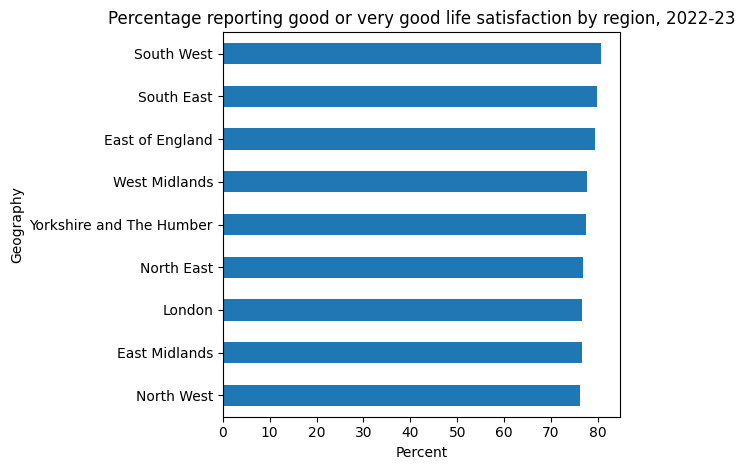

In [24]:
import matplotlib.pyplot as plt
combined.sort_values().plot(kind='barh')
plt.title('Percentage reporting good or very good life satisfaction by region, 2022-23')
plt.xlabel('Percent')
plt.tight_layout()
plt.show()